# Forecasting the COVID-19 Pandemic Evolution in Querétaro through the Kermack-McKendrick model
---
*March 9th, 2026 (a reinterpreted version of a project from November 25th, 2020)*

This is a research project conducted under the guidance of [Dr. Ulises Velasco](https://orcid.org/0000-0002-2630-9095) and in collaboration with [Ing. Oscar Mena](linkedin.com/in/mena-oscar), in which a projection of the evolution of the COVID-19 pandemic in Querétaro, Mexico was made. The dataset was curated from the [public archive](https://gobqro.tumblr.com/archive/2020/10) of the Government of the State of Querétaro, covering 6 months and 22 days (April 4, 2020 - October 27, 2020).

The SIR model was used to estimate the number of infected people, recovered people, the peak of infections, and the approximate date when it will occur. Additionally, the 4th-order Runge-Kutta method was used to solve the system of differential equations numerically.

In [159]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import pathlib, os, sys, requests
from datetime import datetime, timedelta

# ──────────────────────────────────────────────────────────────────────────────
# The following functions represent S'(t), I'(t) and R'(t) of the SIR model. 
# These are numerically solved using the 4th-order Runge-Kutta model.
# ──────────────────────────────────────────────────────────────────────────────

def dS(s: float, i: float, beta: float) -> float:
    """S'(t) = -β*S*I"""
    return -beta * s * i

def dI(s: float, i: float, beta: float, gamma: float) -> float:
    """I'(t) = β*S*I - γ*I"""
    return beta * s * i - gamma * i

def dR(i: float, gamma: float) -> float:
    """R'(t) = γ*I"""
    return gamma * i

### COUPLED RK4 SOLVER

In [160]:
def solve_sir_rk4(
    S0: float, I0: float, R0: float,
    beta: float, gamma: float,
    days: int = 900, h: float = 0.05
) -> pd.DataFrame:
    """
    Solve the SIR system with RK4 on the coupled vector [S, I, R].

    Parameters
    ----------
    S0, I0, R0 : initial conditions
    beta       : transmission rate (per person per day)
    gamma      : recovery rate (per day)
    days       : forecast horizon in days
    h          : RK4 step size (days)

    Returns
    -------
    DataFrame with integer-day snapshots indexed by step number.
    """
    n_steps = int(days / h)
    S = np.zeros(n_steps)
    I = np.zeros(n_steps)
    R = np.zeros(n_steps)

    S[0], I[0], R[0] = S0, I0, R0

    for n in range(n_steps - 1):
        sn, i_n, rn = S[n], I[n], R[n]

        # --- Stage 1 ---
        ks1 = dS(sn, i_n, beta)
        ki1 = dI(sn, i_n, beta, gamma)
        kr1 = dR(i_n, gamma)

        # --- Stage 2 ---
        s2 = sn + 0.5 * h * ks1
        i2 = i_n + 0.5 * h * ki1
        ks2 = dS(s2, i2, beta)
        ki2 = dI(s2, i2, beta, gamma)
        kr2 = dR(i2, gamma)

        # --- Stage 3 ---
        s3 = sn + 0.5 * h * ks2
        i3 = i_n + 0.5 * h * ki2
        ks3 = dS(s3, i3, beta)
        ki3 = dI(s3, i3, beta, gamma)
        kr3 = dR(i3, gamma)

        # --- Stage 4 ---
        s4 = sn + h * ks3
        i4 = i_n + h * ki3
        ks4 = dS(s4, i4, beta)
        ki4 = dI(s4, i4, beta, gamma)
        kr4 = dR(i4, gamma)

        S[n + 1] = sn + (h / 6) * (ks1 + 2*ks2 + 2*ks3 + ks4)
        I[n + 1] = i_n + (h / 6) * (ki1 + 2*ki2 + 2*ki3 + ki4)
        R[n + 1] = rn + (h / 6) * (kr1 + 2*kr2 + 2*kr3 + kr4)

    steps = np.arange(n_steps)
    day_vals = steps * h

    df = pd.DataFrame({"day": day_vals, "Susceptible": S, "Infected": I, "Recovered": R})
    # Keep only integer-day rows df_SIR[df_SIR["Date"] % 1 == 0]
    df = df[np.isclose(df["day"] % 1, 0)].copy()
    df["day"] = df["day"].astype(int)

    return df

### DATA LOADERS

In [161]:
def load_local_data(csv_path: str) -> dict:
    """Load the original Querétaro CSV and extract SIR parameters."""
    df = pd.read_csv(csv_path).fillna(0)
    df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
    df["Beta"]  = df["Beta"].astype(str).str.replace(",", ".").astype(float)
    df["Gamma"] = df["Gamma"].astype(str).str.replace(",", ".").astype(float)
    df = df.sort_values("Date").reset_index(drop=True)

    return {
        "beta":  df["Beta"].mean(),
        "gamma": df["Gamma"].mean(),
        "S0":    df["Susceptible"].iloc[0],
        "I0":    df["Infected"].iloc[0],
        "R0":    df["Recovered_SIR"].iloc[0],
        "start_date": df["Date"].iloc[0],
        "source": "Local CSV – Querétaro",
    }

### PLOTTING

In [162]:
def plot_sir(df_sir: pd.DataFrame, params: dict, location: str = ""):
    """Plot the SIR curves with peak annotation."""
    peak = df_sir.loc[df_sir["Infected"].idxmax()]
    N    = params["S0"] + params["I0"] + params["R0"]
    final= df_sir.loc[df_sir["Susceptible"].idxmin()]
    percentage = (1 - final["Susceptible"] / N) * 100

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(df_sir.index, df_sir["Susceptible"] / 1e6, color="green",
            label="Susceptible", linewidth=2)
    ax.plot(df_sir.index, df_sir["Infected"]    / 1e6, color="red",
            label="Infected",    linewidth=2)
    ax.plot(df_sir.index, df_sir["Recovered"]   / 1e6, color="blue",
            label="Recovered",   linewidth=2)

    ax.axvline(peak.name, color="orange", linestyle="--", linewidth=1.5,
               label=f"Peak: {peak.name.strftime('%d %b %Y')}")

    # Annotations
    ax.annotate(
        f"Peak infections\n{round(peak['Infected'] / 1e3):,}k people\n{peak.name.strftime('%d %b %Y')}",
        xy=(peak.name, peak["Infected"] / 1e6),
        xytext=(20, 20), textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color="black"),
        fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow")
    )

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

    title = f"SIR Model – {location or params['source']}"
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Millions of People")
    ax.legend()
    ax.grid(alpha=0.3)

    print(f"\n{'─'*60}")
    print(f"  Source  : {params['source']}")
    print(f"  β       : {params['beta']:.8f}  |  γ : {params['gamma']:.8f}")
    print(f"  Peak    : {peak.name.strftime('%d %b %Y')} "
          f"({round(peak['Infected']):,} infected)")
    print(f"  Total infected by end: {percentage:.2f}% of population")
    print(f"{'─'*60}\n")

    plt.tight_layout()
    plt.show()
    return fig

### MAIN

In [ ]:
def run_sir(params: dict, days: int = 900, h: float = 0.05, location: str = ""):
    """End-to-end: solve SIR and plot, given a params dict."""
    print(f"\n→ Running SIR for: {params['source']}")

    df_sir = solve_sir_rk4(
        S0=params["S0"], I0=params["I0"], R0=params["R0"],
        beta=params["beta"], gamma=params["gamma"],
        days=days, h=h
    )

    # Attach real dates to the integer-day index
    start = pd.Timestamp(params["start_date"])
    df_sir.index = [start + timedelta(days=int(d)) for d in df_sir["day"]]
    df_sir.index.name = "Date"
    df_sir = df_sir.drop("day", axis=1)

    fig = plot_sir(df_sir, params, location=location)
    return df_sir, fig

### Usage


→ Running SIR for: Local CSV – Querétaro

────────────────────────────────────────────────────────────
  Source  : Local CSV – Querétaro
  β       : 0.00000006  |  γ : 0.10101121
  Peak    : 23 Jan 2021 (76,058 infected)
  Total infected by end: 44.94% of population
────────────────────────────────────────────────────────────



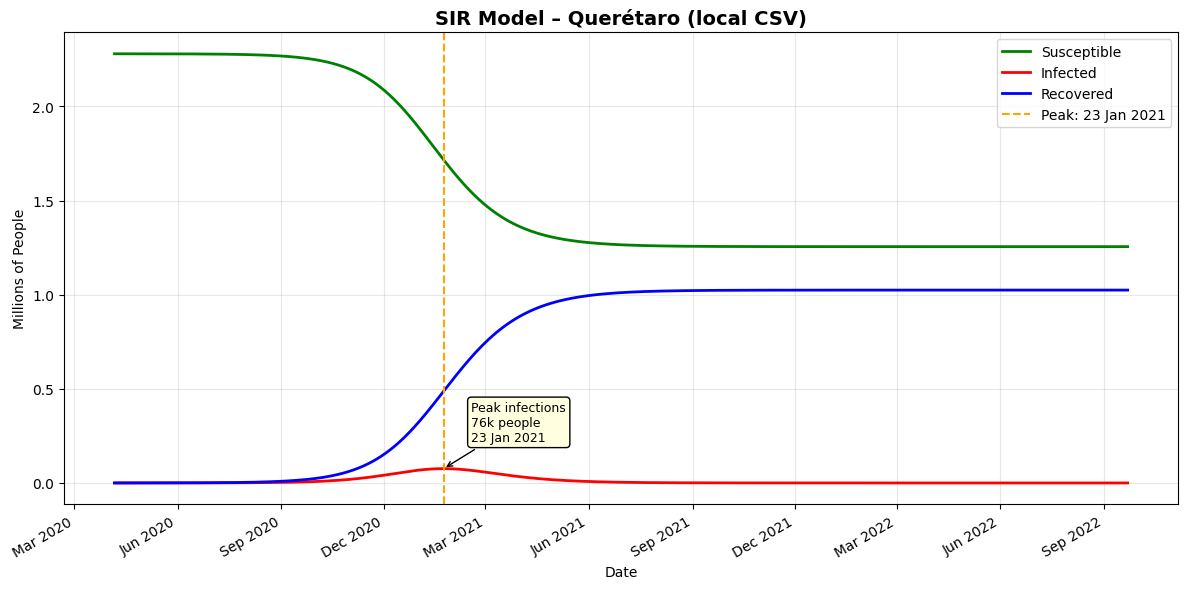

In [164]:
LOCAL_CSV = r"data\Covid-19 Queretaro.csv"
if pathlib.Path(LOCAL_CSV).exists():
    params_local = load_local_data(LOCAL_CSV)
    run_sir(params_local, location="Querétaro (local CSV)")

In [165]:
# # Export values in CSV format
# fileCSV = open("SIR_RK4_Covid_19-Qro.csv", "w")
# fileCSV.write("Day, Susceptible, Infected, Recovered\n")
# validDays = range(900)
# for n in range(int(days/h) - 1):
#     if (n*h) in validDays:
#         fileCSV.write(f"{n*h}, {int(Sus[n])}, {int(Inf[n])}, {int(Rec[n])}\n")
# fileCSV.close()